# ATP Tennis Match Prediction (2000-2024)
---
---

## 1. Introduzione e Obiettivi

L'obiettivo di questo progetto è sviluppare un modello di Machine Learning basato due modelli di allenamento in grado di predire il vincitore di una partita di tennis professionistico ATP.
Il tennis è uno sport caratterizzato da una forte componente stocastica, ma anche da pattern storici ben definiti come gerarchie di ranking, punteggio di ELO, adattamento alle superfici, scontri diretti.

I dati utilizzati provengono dal repository pubblico di Jeff Sackmann (https://github.com/JeffSackmann/tennis_atp/tree/master). Il dataset completo copre l'arco temporale 1968-2024. Per questo progetto abbiamo scelto di iniziare dall'anno 2000 per garantire una maggiore consistenza nella raccolta statistica (es. minuti giocati, ace, doppi falli) che negli anni precedenti era spesso frammentaria.

---
---

## 2. Data Ingestion & Merging
I dati grezzi sono suddivisi in file CSV annuali (un file per anno). Il primo passo della pipeline è l'aggregazione di questi file in un unico DataFrame Pandas cronologicamente ordinato.
Durante la fase di ingestionrecupero dei dati, abbiamo applicato i seguenti filtri per garantire una qualità alta del dato:
- Esclusione dei tornei "Futures": I dati relativi ai tornei minori (Futures) sono stati esclusi. Questi match presentano spesso statistiche incomplete o inaffidabili e introducono un elevato livello di rumore che potrebbe confondere il modello.
- Esclusione delle Qualificazioni: Sono stati considerati solo i match dei tabelloni principali del circuito ATP e Challenger.
- Parsing delle Date: La colonna tourney_date è stata convertita immediatamente in formato datetime per permettere il futuro split cronologico per il Training e il Testing evitando il Data Leakage temporale.

Come prima cosa sono stati sono stati scaricati i dataset da GitHub e sono stati inseriti nella cartella 'datasets'
Una volta impostato il nome del file mergiato, viene creato un dataframe temporaneo contenente tutti i dataset annuali in cui le date dei match sono state convertite nel formato datetime.

Per scrupolo il dataset viene ordinato secondo 'tourney_date' per rispettare esattamente la realtà temporale. Questo passaggio è fondamentale perchè L'algoritmo ELO (che calcoleremo successivamente) è calcolato ricorsivamente: il punteggio di un giocatore oggi dipende dal risultato della partita precedente.
Ordiniamo prima per Data (tourney_date). A parità di data (es. tutti i match del primo turno di Wimbledon), usiamo l'ID del torneo e il numero del match (match_num) per mantenere la sequenza logica del tabellone.

Infine salviamo il risultato in un nuovo file CSV (atp_matches_2000_2024_raw.csv).

---
---

## 3. Data Cleaning e Strategie di Imputazione
Analizzando il dataset abbiamo notato la presenza di valori mancanti (NaN) in diverse colonne chiave. Poichè non è possibile semplicemente rimuovere le righe con dati mancanti (che costituirebbero una perdita significativa di informazioni), né riempirle ciecamente con la media. Abbiamo quindi adottato strategie di imputazione differenziate basate sulla natura del dato.

1) Imputazione basata su Domain Knowledge (Seeds e Entry):
Nel tennis, se un giocatore non ha una "Testa di Serie" (seed), non è un dato mancante per errore: significa semplicemente che non è tra i favoriti (top 32).La strategia è quella di riempire i NaN con il valore 100 così che il modello numerico capisca che una testa di serie "Mancante" vale meno di una testa di serie n. 1 o n. 32. Il numero 100 agisce come un valore alto fittizio.
Similmente, per l'entry (tipo di ingresso al torneo), i valori vuoti indicano ingressi standard (STD).

2) Imputazione con Valori Sentinella (Ranking):
I giocatori senza ranking (spesso a inizio carriera) vengono riempiti con un ranking fittizio basso (2000) e punti 0. Questo permette al modello di trattarli come "giocatori di bassa classifica" senza dover scartare la partita.

3) Imputazione Statistica (Dati Fisici):
Per Età e Altezza, la mancanza del dato è data da una registrazione del valore non effattuata. Abbiamo deciso di utilizzare la media del dataset per età e altezza.
Per la Mano dominante, utilizziamo la moda, ovvero 'R' (Right-handed), dato che i mancini sono una minoranza statistica.

4) Gestione Statistiche Tecniche:
Per le statistiche del match (Ace, Doppi Falli, Punti Vinti), i valori mancanti sono critici. Abbiamo quindi deciso di riempirli con -1 (valore impossibile nel tennis).In questo modo queste colonne non verranno usate direttamente per la predizione, ma serviranno per calcolare le medie storiche. Il valore -1 servirà da "flag" per riconoscere alle quali partite ignorare nel calcolo della media ace, poichè i dati non sono completi

---
---

# 4 Feature Engineering
In questa fase trasformiamo i dati grezzi in indicatori predittivi. L'obiettivo è arricchire il dataset con informazioni che catturino:
- Forza Relativa tramite l'ELO
- Stato di forma tramite il momentum di vittorie
- Trend di crescita tramite i gradient
- Esperienza e scontri su varie superfici

---

### 4.1 Funzioni di Supporto
Uno dei problemi principali dei sistemi ELO è l'avvio (Cold Start). Se iniziassimo l'analisi nel Gennaio 2000 assegnando a tutti i giocatori un punteggio standard di 1500, il modello impiegherebbe anni per allinearsi alla realtà, trattando leggende come Andre Agassi (allora N.1) come esordienti.

Per mitigare questo problema, utilizziamo la funzione load_initial_rankings, che attinge allo storico dei ranking anni '90 per generare una "fotografia" dello stato dell'arte al 31 Dicembre 1999.

Poiché il ranking ATP è lineare (1, 2, 3...) ma la differenza di abilità non lo è (il divario tra il N.1 e il N.10 è molto più ampio di quello tra il N.100 e il N.110), utilizziamo una scala logaritmica per convertire la posizione in classifica in un punteggio ELO iniziale:
$$ELO_{init} = 2500 - 300 \cdot \log_{10}(\text{Rank})$$

- Abbiamo impostato un Safety Floor a 1400 punti per evitare valori eccessivamente bassi per i giocatori di bassa classifica.

Per far funzionare correttamente il K-Factor Dinamico (spiegato in dettaglio più avanti), il sistema deve sapere se un giocatore è un veterano o un novellino. Poiché non abbiamo il conteggio esatto delle partite giocate prima del 2000, lo stimiamo basandoci sul ranking:

- Top 10: 500 partite
- Top 50: 300 partite
- Top 100: 150 partite
- top 500: 50 partite
- tutti gli altri 10

Un fattore determinante per l'accuratezza del sistema ELO è il K-factor, la costante che stabilisce la velocità con cui il punteggio di un giocatore reagisce ai nuovi risultati.Dopo una fase di sperimentazione iniziale con formule continue, abbiamo optato per un approccio "Tiered" (a scaglioni), simile a quello utilizzato negli scacchi agonistici. Questa scelta è stata dettata dalla necessità di mantenere il sistema reattivo anche per i veterani con migliaia di partite (es. Djokovic), evitando che il loro ELO diventasse troppo "inerziale" o statico.Il valore base del K-Factor ($K_{base}$) viene assegnato in base all'esperienza del giocatore (numero di partite giocate, $M$), seguendo tre fasce di stabilità:$$K_{base} =
\begin{cases}
50 & \text{se } M < 30 \quad (\text{Esordienti: Alta Volatilità}) \\
40 & \text{se } 30 \le M < 100 \quad (\text{Emergenti: Media Volatilità}) \\
32 & \text{se } M \ge 100 \quad (\text{Veterani: Stabilità Reattiva})
\end{cases}$$Esordienti ($K=50$): Permette al sistema di calibrare molto rapidamente il livello reale di un nuovo talento.Veterani ($K=32$): Assicura stabilità, ma mantiene un valore sufficientemente alto (standard competitivo) per penalizzare significativamente anche i campioni in caso di sconfitte inattese.Ponderazione per Importanza del TorneoIn aggiunta all'esperienza, abbiamo raffinato il modello applicando dei moltiplicatori ($K_{mult}$) basati sul prestigio del torneo. L'assunto è che nei tornei maggiori la motivazione e l'impegno siano massimi, rendendo il risultato più veritiero rispetto ai tornei minori.La formula finale è:

$K = K_{base} \cdot K_{mult}$

con i seguenti coefficienti:

Grand Slam: $K_{mult} = 1.1$ 

Masters 1000 e ATP Finals: $K_{mult} = 1.05$

ATP 250 / 500 / Challenger: $K_{mult} = 1.0$


---

### 4.2 Matematica dell'ELO
Un primo attributo che ci è sembrato necessario inserire è l'ELO, questo attributo assegna un punteggio di forza relativo ad ogni giocatore che, a differenza del ranking ATP (si basa i punti dell'anno precedente), l'ELO è un sistema che si aggiorna partita dopo partita.
Ogni giocatore sconosciuto inizia la sua carriera con un rating ELO di 1500 e questo valore (che chiameremo R) si aggiorna dopo ogni partita giocata, l'aggiornamento segue questa regola:
$$R_{new} =R + K \cdot (S - E)$$

In questa formula è presente la variabile S che indica il risultato della partita (S=1 se il giocatore ha vinto, S=0 se il giocatore ha perso), è inoltre presente la variabile E che indica l'aspettativa di vittoria del giocatore A in quella partita contro il giocatore B ed è calcolata in questo modo:
$$E_A = \frac{1}{1 + 10^{(R_{mix}^B - R_{mix}^A) / 400}}$$

Il denominatore 400 definisce la "Larghezza" della curva ovvero stabilisce quanta differenza di punti serve per avere una certa probabilità di vittoria. Con una differenza di 400 punti un giocatore ha una probabilità del 91% di vincere la partita

Un dettaglio importante da notare è che utilizziamo $R_{mix}$ per indicare il rating ELO per ogni giocatore perchè per ogni match, calcoliamo un rating misto che combina l'ELO Generale ($R_{overall}$) e quello di Superficie ($R_{surface}$), questo per riflettere lla dominanza di alcuni giocatori su certe superfici di gioco:

$$R_{mix} = 0.6 \cdot R_{overall} + 0.4 \cdot R_{surface}$$

---

### 4.3 Simulazione Storica
La funzione calculate_features agisce come una simulazione cronologica che ripercorre l'intera storia del tennis dal 2000 al 2024, partita dopo partita.

L'algoritmo segue un rigoroso processo a 3 Fasi per ogni singola riga del dataset, eliminando tutte quelle features che rappresentano un data leakage.

**Fase 1: Inizializzazione e Memoria**
Prima di avviare il ciclo cronologico, è fondamentale inizializzare correttamente le strutture dati che terranno traccia dello stato del sistema.
- elo_overall: Dizionario che mantiene il punteggio ELO corrente. Inizializzato con i valori storici (o 1500 per i nuovi).
- elo_surface: Dizionario per tracciare l'ELO specifico per ogni superficie (Hard, Clay, Grass, Carpet).
- matches_played: Contatore necessario per calcolare il K-Factor Dinamico.
- win_history: Una coda (deque) per ogni giocatore che memorizza gli ultimi risultati (1 o 0). Serve per calcolare la Forma.
- elo_history: Traccia l'evoluzione dell'ELO nel tempo per calcolare il Gradiente (Trend di crescita).
- feats: Un dizionario di liste vuote. Invece di scrivere riga per riga nel DataFrame (lento), accumuliamo qui i risultati e li uniamo solo alla fine.

**Fase 2: Funzioni ausiliarie**
All'interno del ciclo di calcolo, definiamo due funzioni ausiliarie per estrarre indicatori dinamici dalla memoria storica. Queste funzioni implementano il concetto di "Rolling Window".

- get_win_pct(pid, n) - La Forma: Calcola la percentuale di vittorie nelle ultime $n$ partite. Un giocatore che ha vinto l'80% delle ultime 5 partite (w_win_last_5 = 0.8) è probabilmente in uno stato di fiducia mentale superiore rispetto a uno con lo stesso ELO ma che ne ha vinto solo il 20%.

- get_elo_gradient(pid, n) - Il Trend: Misura la variazione netta di punteggio ELO negli ultimi $n$ match.
$$Gradient = ELO_{t} - ELO_{t-n}$$
Serve a distinguere la traiettoria della carriera.Gradiente Positivo (+50): Il giocatore sta migliorando rapidamente (es. un giovane in ascesa).Gradiente Negativo (-50): Il giocatore sta peggiorando (es. rientro da infortunio o declino fisico).Gradiente Nullo (~0): Le prestazioni sono stabili (es. un giocatore esperto).

**Fase 3: Ciclo Principale**
Il cuore dell'algoritmo è un ciclo iterativo che processa le partite in rigoroso ordine cronologico. Per ogni riga del dataset, il sistema esegue quattro operazioni sequenziali:

1. Gestione Dinamica dei Nuovi Giocatori: Non tutti i giocatori sono presenti dal 2000. Quando un "nuovo" giocatore (es. Carlos Alcaraz nel 2020) appare per la prima volta, il sistema lo rileva e lo inizializza
2. Snapshot Pre-Match: Salviamo i dati (ELO, H2H, Forma, ...) nelle liste di output PRIMA di elaborare il risultato della partita corrente
3. Calcolo delle Rolling Features: Invochiamo le funzioni ausiliarie get_win_pct e get_elo_gradient su diverse finestre temporali (5, 25, 50 partite) per catturare sia la forma a breve termine che i trend a lungo termine.
4. Aggiornamento Post-Match: Una volta salvati i dati per il training, il sistema "osserva" il risultato reale, calcola la probabilità attesa e aggiorna l'ELO dei due giocatori, incrementa il contatore delle partite e aggiorna la memoria storica, influenzando così il K-Factor e le statistiche per il match successivo.

--- 

### 4.4 Preparazione finale per il Machine Learning
Il dataset prodotto finora ha una struttura rigida: ogni riga ha un winner_... e un loser_... Questo formato non è adatto all'addestramento di una Rete Neurale per due motivi:
- Data Leakage Implicito: Il modello capirebbe banalmente che il giocatore nelle colonne "Winner" è quello che vince.
- Mancanza di Generalizzazione: Vogliamo che il modello impari a valutare una sfida tra "Giocatore A" e "Giocatore B", indipendentemente dall'ordine.

La funzione transform_to_ml_format risolve questi problemi applicando tre trasformazioni:
**A. Encoding Variabili Categoriche**

Abbiamo trasformato le variabili categoriche utilizzando strategie diverse in base alla natura del dato:
- Superficie (One-Hot Encoding):Le superfici (Hard, Clay, Grass, Carpet) sono nominali: non esiste un ordine intrinseco.Abbiamo creato 4 colonne binarie indipendenti (es. surface_Clay: 1 se terra, 0 altrimenti). Questo permette al modello di identificare correttamente gli "specialisti" di ogni terreno.
- Turno del Torneo (Ordinal Encoding):A differenza della superficie, i turni possiedono una gerarchia chiara.Abbiamo mappato i turni su una scala numerica crescente (R128 = 1 $\rightarrow$ Finale = 7). In questo modo, il modello può interpretare matematicamente l'aumento progressivo della difficoltà e della tensione man mano che il torneo avanza.
- Mano (Binary Encoding):Dopo lo scambio casuale, convertiamo l'informazione sulla mano dominante ('L'/'R') in una variabile binaria is_left (1 se mancino, 0 se destro).

**B. Anonimizzazione e Random Swapping**
Trasformiamo le etichette Winner/Loser in Player 1 (P1) e Player 2 (P2). Successivamente, applichiamo un Random Swap sul 50% delle righe:
- Nel 50% dei casi: P1 è il Vincitore quindi il valore di Target sarà 1
- Nel 50% dei casi: P1 è il Perdente quindi il valore di Target sarà 0

Questo garantisce che le classi siano perfettamente bilanciate e che il modello non abbia bias posizionali.

**C. Feature Differenziali**
Le Reti Neurali apprendono molto più efficacemente dalle differenze relative che dai valori assoluti. Invece di fornire P1_ELO = 2000 e P2_ELO = 1900, forniamo:
$$\Delta ELO = P1_{ELO} - P2_{ELO} = +100$$

Calcoliamo le differenze per tutte le metriche chiave: DIFF_ELO, ATP_RANK_DIFF, WIN_LAST_X_DIFF, ELO_GRAD_X_DIFF, DIFF_N_GAMES, diff_age, diff_ht. 

---

### 4.5 Esecuzione della Pipeline
In questa fase, viene eseguito l'intero processo di elaborazione. Il flusso di lavoro segue 4 step sequenziali:

1. Inizializzazione: Carichiamo i ranking storici degli anni '90 per risolvere il problema del Cold Start e assegnare i valori iniziali di ELO ed esperienza.

2. Core Processing (La Simulazione): Eseguiamo calculate_features sul dataset completo. Questa operazione richiede tempo poiché ripercorre cronologicamente oltre 70.000 partite, aggiornando lo stato del sistema match dopo match.

3. Trasformazione ML: Convertiamo il dataset arricchito in un formato pronto per la Rete Neurale (Encoding, Random Swap, Differenziali).

4. Export dei Dati: Generiamo due file distinti:

- dataset_enriched.csv: Il file "leggibile" (con Winner/Loser), utile per l'analisi umana e il debugging.

- dataset_ml_ready.csv: Il file "anonimizzato" e numerico (P1/P2, Target 0/1), che sarà l'input effettivo per il training del modello.

---

### 4.6 Creazione Snapshot 2025

Per rendere utilizzabile il modello su eventi futuri, abbiamo creato uno "snapshot" dello stato di ciascun giocatore all'inizio del 2025. Lo snapshot è salvato nel file `players_2025_ready.csv` ed è pensato come tabella di riferimento per generare probabilità di vittoria in qualsiasi accoppiamento (P1 vs P2) senza data leakage.

Obiettivi dello snapshot:
- Coerenza temporale: tutte le metriche sono calcolate usando esclusivamente dati fino all'ultima partita disputata da ogni giocatore entro il 31/12/2024.
- Copertura informativa: include ELO generale e di superficie, forma recente, esperienza e variabili anagrafiche.

Campi principali (indicativi):
- `player_id`, `player_name`, `hand`, `age`, `height`: anagrafica aggiornata all’ultima apparizione.
- `elo_overall_2024_end`, `elo_clay_2024_end`, `elo_hard_2024_end`, `elo_grass_2024_end`: valori ELO finali per ogni superficie e generale.
- `win_last_5`, `win_last_25`, `win_last_50`: forma recente su finestre rolling.
- `elo_grad_5`, `elo_grad_25`, `elo_grad_50`: gradienti (trend) dell’ELO.
- `n_matches_total`, `n_matches_surface_*`: esperienza complessiva e per superficie.
- `last_seen_date`: data dell’ultimo match (utile per gestire lunghi periodi di inattività).

Procedura di costruzione:
1) Ordinamento cronologico del dataset completo e calcolo incrementale delle metriche.
2) Aggregazione per giocatore prendendo l’ultimo stato disponibile al 31/12/2024.
3) Normalizzazioni leggere (es. bounding di gradienti e win% tra 0 e 1) per evitare outliers estremi.
4) Salvataggio della tabella finale (`players_2025_ready.csv`).

Note di qualità:
- Giocatori con pochissime partite nel 2024 possono avere metriche rumorose: lo snapshot conserva comunque i valori per garantire copertura ma ovviamente la loro predizione sarà più incerta


---
---

## 5. Explorative Data Analysis (EDA)

L'analisi esplorativa mira a validare le ipotesi statistiche alla base del progetto e a verificare la capacità discriminante delle feature create prima di darle in pasto alla Rete Neurale.

---

### 5.1 Analisi delle correlazioni

La Matrice di Correlazione Estesa rivela la gerarchia delle forze in gioco:

- La feauture più importante: `DIFF_ELO` mostra la relazione più alta con `target` (0.39). Ciò conferma che il sistema ELO cattura la forza meglio del semplice ranking.
- Punti ATP vs Rank: La correlazione tra `target` e `ATP_POINT_DIFF` (0.30) è superiore a quella tra `target` e `ATP_RANK_DIFF` (0.22). Quindi il numero di punti è un segnale più potente rispetto alla sola differenza di posizione in classifica. 
- Importanza della forma: La forma a lungo termine `WIN_LAST_50_DIFF` (0.31) è superiore alla forma a breve termine `WIN_LAST_5_DIFF` (0.21). Questo indica che la costanza nel lungo periodo è più indicativa rispetto a picchi di vittorie momentanei.
- Multicollinearità: Notiamo un'alta correlazione (0.75) tra `DIFF_ELO` e `ATP_POINT_DIFF`. Questo è previsto, ma suggerisce che il modello dovrà imparare a pesare queste due misure di "forza" che sono parzialmente ridondanti.

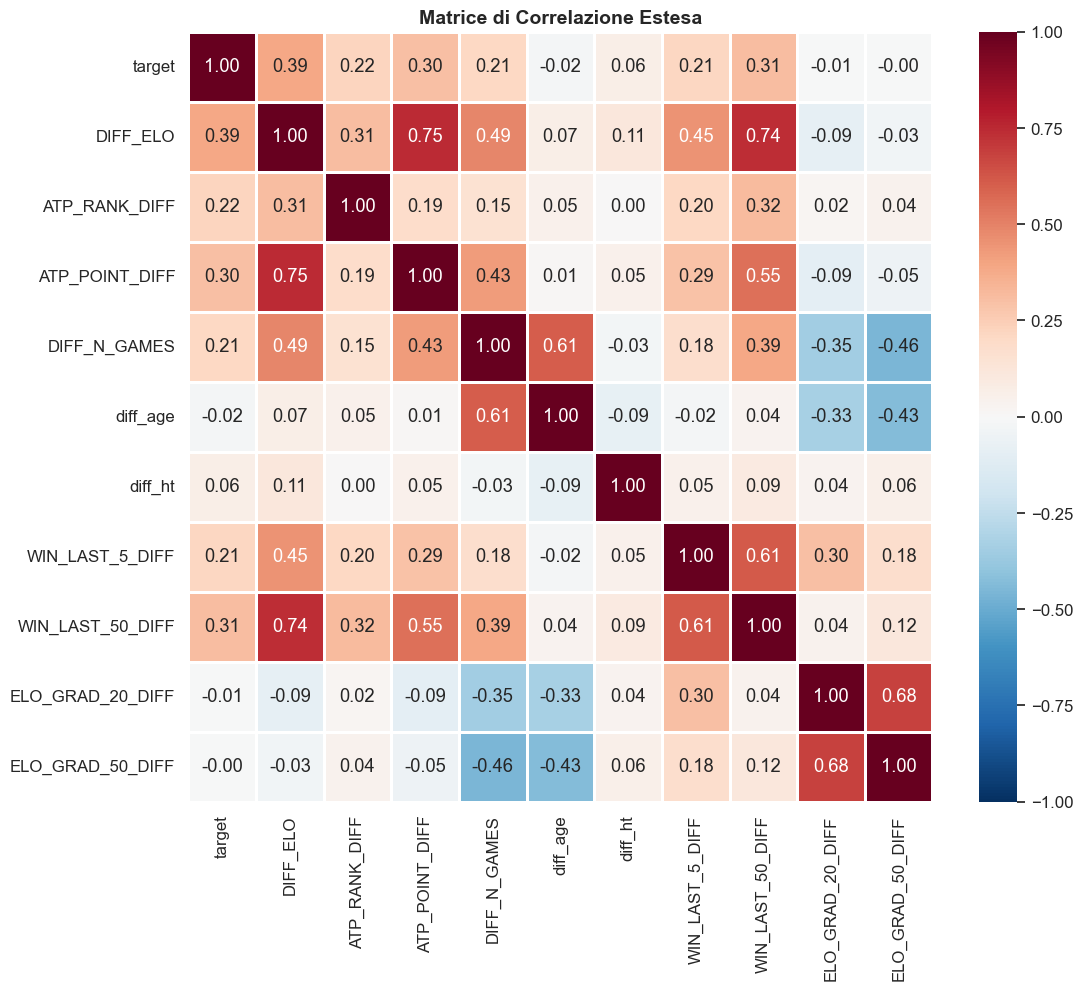


---

### 5.2 Evoluzione storica 

Il grafico dell'Evoluzione Storica ELO confonta tre campioni: Novak Djokovic, Jannik Sinner e Carlos Alcaraz.

- Dominio e Stabilità: È evidente la straordinaria longevità di Djokovic, che ha mantenuto un ELO sopra i 2400 per quasi vent'anni, con picchi vicini a 2900. 
- Ascesa: Si osserva chiaramente il trend di crescita verticale dei tre campioni all'inizio della carriera. Nonostante le poche partite, poche vittorie nei tornei importanti li portano subito ad avere un ELO da campioni, grazie alla divisione in scaglioni per il calcolo del K-factor.
- Validazione dinamica: Il sistema riflette i cali di forma e periodi di inattività, confermando la bontà della simulazione cronologica. 

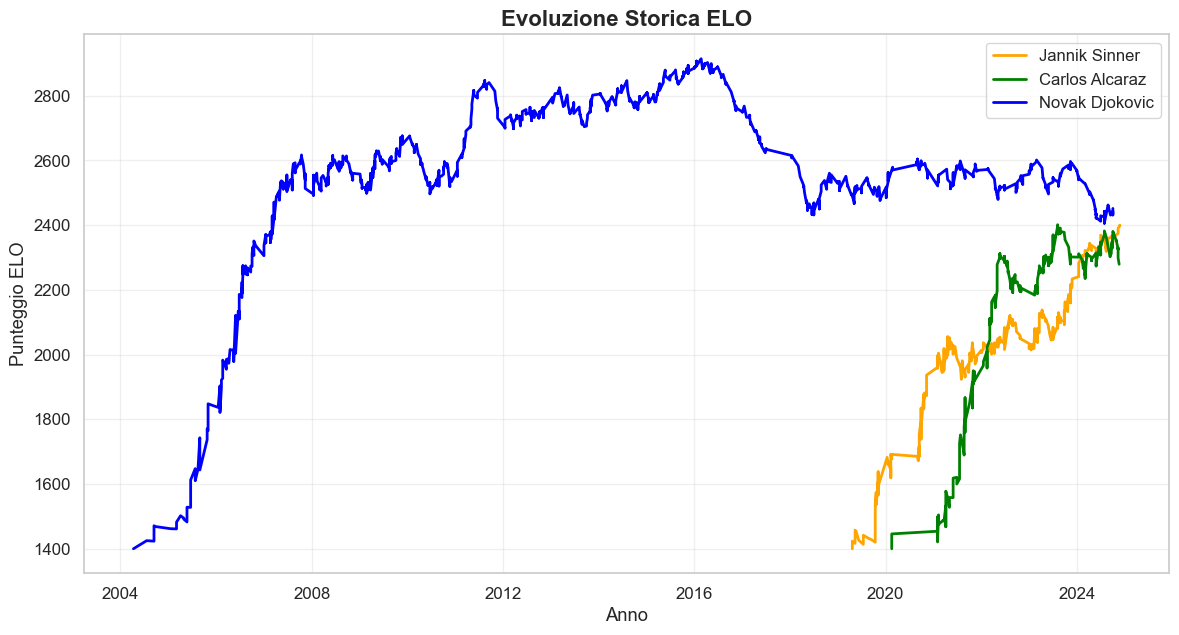

---

### 5.3 Validazione e Calibrazione ELO

Il grafico di Validazione è fondamentale per capire se la matematica dell'ELO è corretta per il tennis moderno:

- Sottostima della Teoria Standard: La curva grigia (Teoria standard con fattore 400, basata sugli scacchi) indica la probabilità teorica di vittoria dato l'ELO. I dati reali però dicono che questa curva risulti troppo ripida. i dati reali mostrano una realtà più incerta. 
- Calibrazione Ottimale: Abbiamo individuato il fattore di scala 650 (linea rossa) che riflette approssimativamente molto meglio la realtà. Questo indica che il tennis è uno sport più "imprevedibile" rispetto alla teoria scacchistica standard. Anche con un grande gap di ELO, l'avversario mantiene una chance di vittoria più alta del previsto.

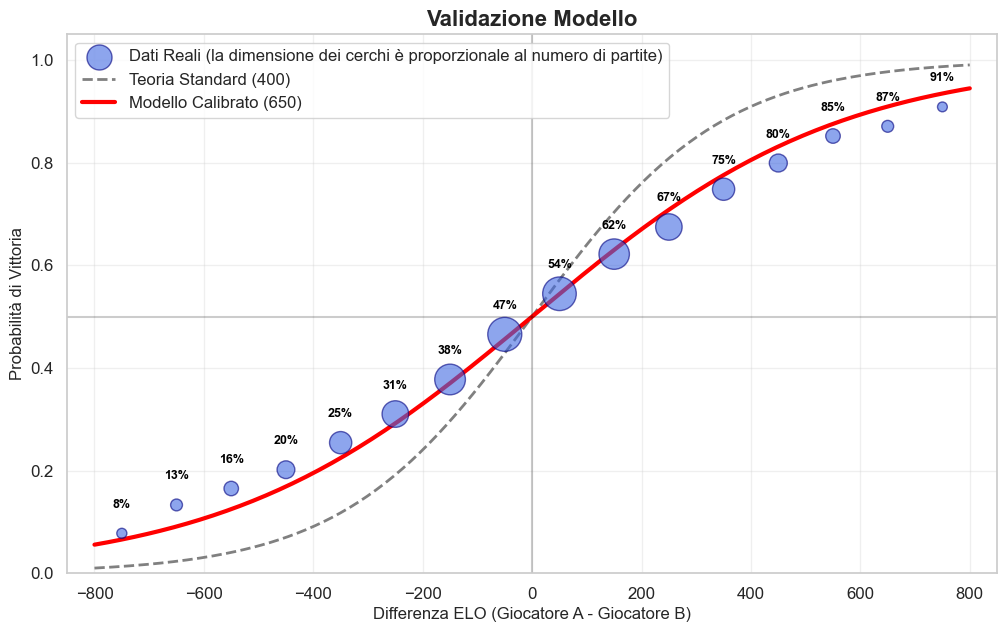

---

### 5.4 Distribuzioni e Relazioni Multidimensionali

Dalle analisi di distribuzione e dai grafici di dispersione emergono ulteriori spunti:

- Distribuzione Età: Il grafico mostra che la differenza di età tra vincitore e perdente è centrata sullo zero con una leggera asimmetria a favore del giocatore più giovane. Questo suggerisce che, pur essendo un fattore, l'età non è un predittore univoco di vittoria, confermando la necessità di feature di più dinamiche che rappresentano una stima della forza di un giocatore.

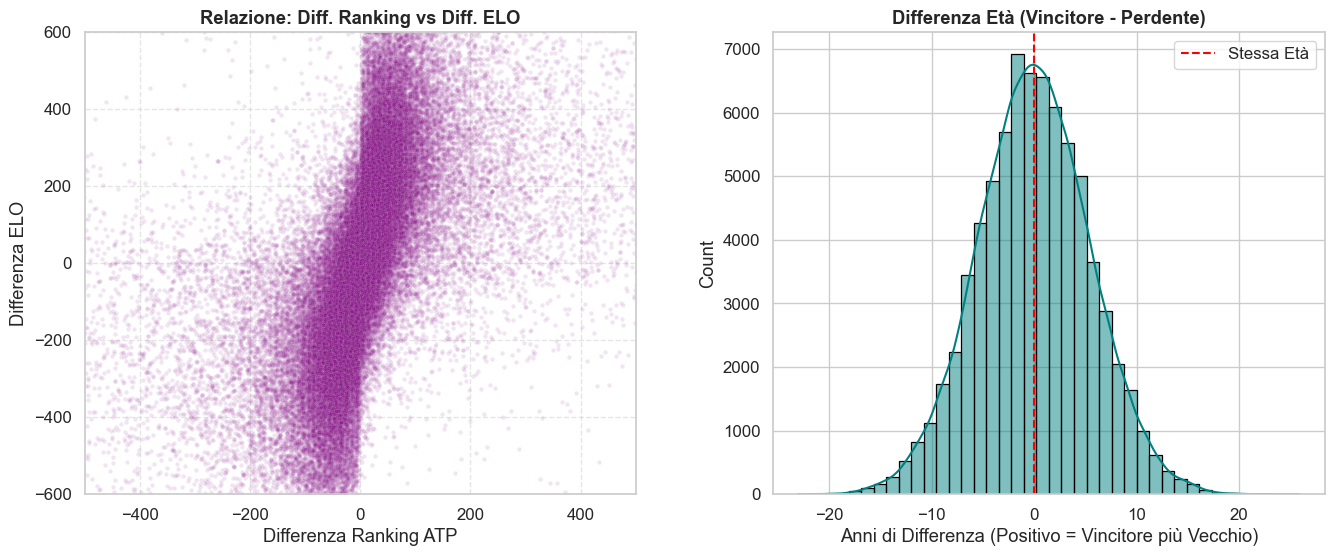

- Separazione delle Classi (Pairplot): Il Pairplot multidimensionale mostra come `DIFF_ELO` e `WIN_LAST_50_DIFF` creino i cluster di "Vittoria/Sconfitta" più definiti (separazione netta tra i punti blu e rossi). Le altre variabili mostrano sovrapposizioni maggiori, indicando che sono utili come rifinitura ma non come predittori primari.

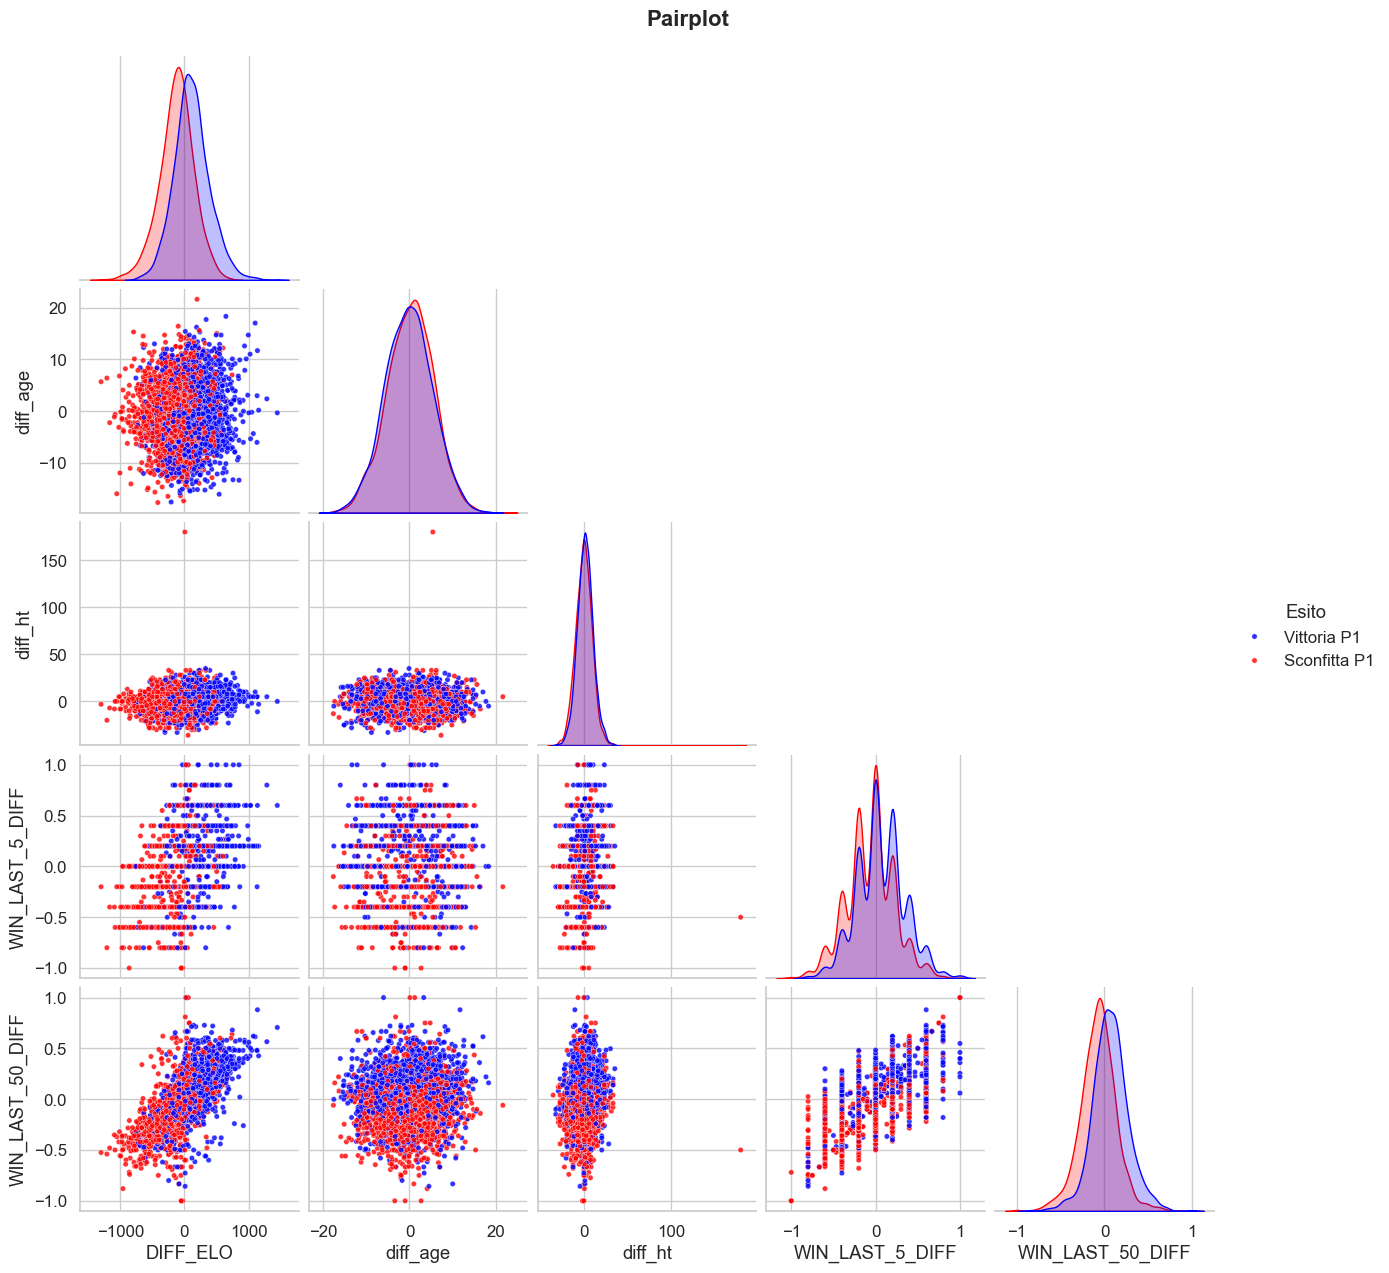


---
---

## 6. Analisi delle Componenti Principali (PCA)

### 6.1 Riduzione della Dimensionalità e Scree Plot
L'analisi è stata condotta su 57 variabili (fisiche, di ranking, ELO e differenziali).

Efficienza della compressione: Lo Scree Plot mostra che l'80% dell'informazione totale (varianza) è contenuta nei primi 16 componenti.

Sintesi: Questo significa che, nonostante l'elevato numero di feature prodotte, il sistema è sintetizzabile in circa un quarto delle dimensioni originali senza perdere segnale significativo. Questo riduce il rischio di overfitting per i modelli successivi.

---
### 6.2 Interpretazione della PC1: Il "Gap di Forza"
La prima componente principale (PC1), che da sola spiega il 15.8% della varianza, è chiaramente definita dalle Feature Differenziali. Analizzando i loadings (i pesi delle variabili sulla componente), notiamo che i valori più alti appartengono a:

- WIN_LAST_100_DIFF (0.294)
- WIN_LAST_50_DIFF (0.286)
- DIFF_ELO (0.278)

Conclusione: La PC1 rappresenta il divario di qualità complessiva tra i due giocatori. Se un match ha un valore elevato di PC1, significa che il Giocatore 1 è nettamente superiore al Giocatore 2 su quasi ogni metrica storica e di performance.

---
### 6.3 Visualizzazione 2D e Separabilità delle Classi
Il grafico PCA 2D Projection (PC1 vs PC2) fornisce una conferma visiva cruciale:

Separazione Netta: Notiamo un gradiente di colore molto marcato lungo l'asse orizzontale (PC1). I punti blu (sconfitte del Giocatore 1) si addensano a sinistra, mentre i punti rossi (vittorie) si spostano verso destra.

Potere Predittivo: Il fatto che le due classi (0 e 1) non siano completamente sovrapposte ma mostrino una tendenza separabile indica che le feature costruite hanno un alto valore informativo. Il rumore di fondo esiste (zona centrale viola), ma i "casi limite" sono ben identificati.

PC2 (Il Contesto): La seconda componente (13.9% var) cattura invece elementi che indicano meno l'esito del match ma piuttosto il contesto del match. Prendendo solo valori assoluti degli atleti, ci darà informazioni sulla portata della partita:
- Se PC2 è alta: Entrambi i giocatori hanno ELO alto e alte percentuali di vittoria. Siamo di fronte a un match tra Campioni (es. una finale di uno Slam).
- Se PC2 è bassa: Entrambi i giocatori hanno valori bassi. Siamo di fronte a un match tra esordienti o giocatori di bassa classifica.

Quindi la componente PC2 non è indicativa sull'esito della partita. 

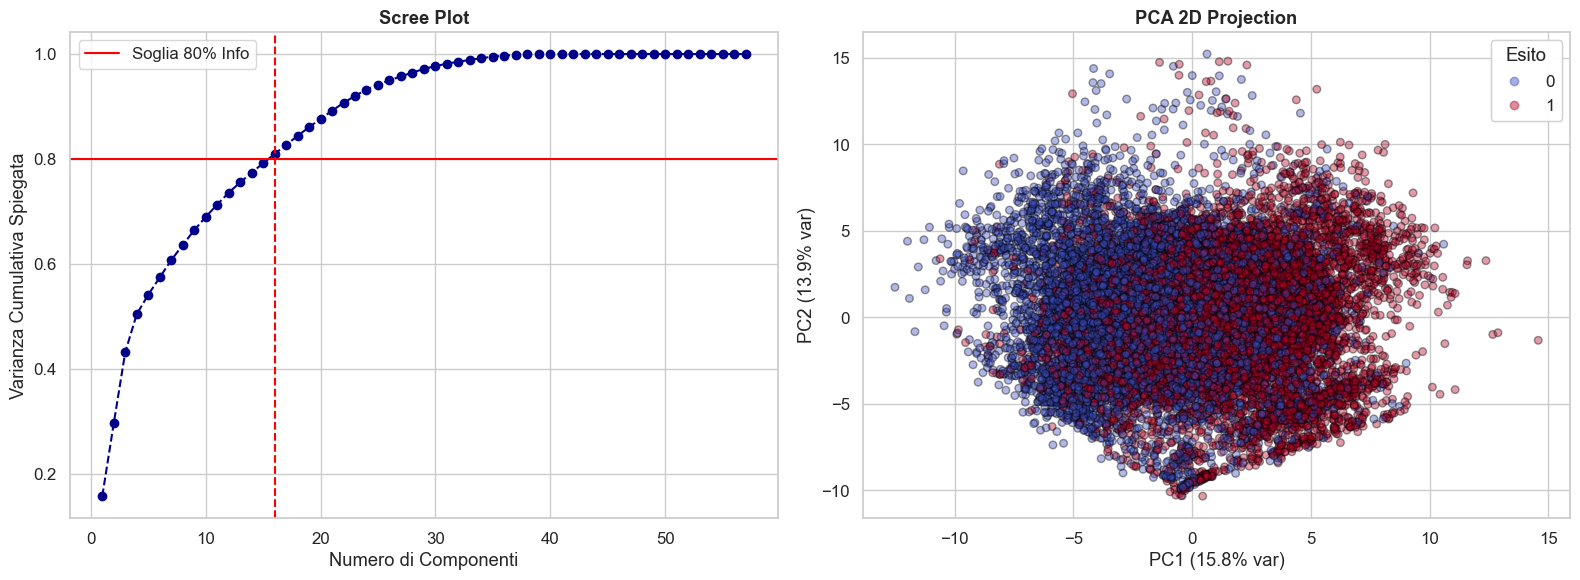



---
---

## 7. Modellazione: Decision Tree (CART)
Il primo approccio alla classificazione è stato effettuato tramite un Albero di Decisione (CART). Questo modello è stato scelto per la sua capacità di catturare relazioni non lineari e per l'elevata interpretabilità dei risultati.

### 7.1 Architettura e Configurazione

Per evitare l'overfitting (sovra-addestramento) e garantire la generalizzazione su dati futuri, il modello è stato configurato con i seguenti iper-parametri:

- Criterio di Scissione: È stata utilizzata l'Entropia per determinare la purezza dei nodi.
- Profondità Massima (max_depth=8): Abbiamo scelto una profondità massima per non rendere troppo specifici i casi cercando di evitare quindi overfitting.
- Minimo Campioni per Foglia (200): Assicura che ogni decisione sia basata su un numero statisticamente significativo di partite, evitando di imparare "rumore" da casi isolati.

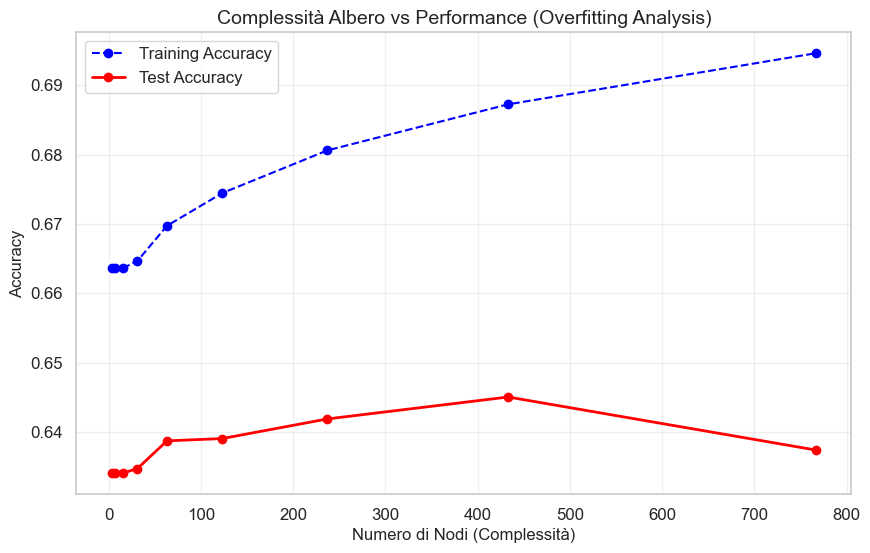

---
### 7.2 Analisi dell'Albero Ottimizzato
Dalla visualizzazione dell'albero emergono gerarchie decisionali molto chiare:

- Il Nodo Radice (Root Split): La prima e più importante decisione viene presa sulla variabile DIFF_ELO <= -39.232. Questo conferma matematicamente quanto visto nell'EDA: l'ELO è il principale spartiacque tra vittoria e sconfitta.
- Variabili Secondarie: Sotto l'ELO, il modello utilizza ATP_RANK_DIFF, ATP_POINT_DIFF e DIFF_SURF_ELO per rifinire la previsione.
- Feature Fisiche: È interessante notare come la differenza di altezza (diff_ht) appaia nei livelli più profondi dell'albero, suggerendo che le caratteristiche fisiche diventino determinanti solo quando i valori tecnici (ELO e Rank) sono molto simili.

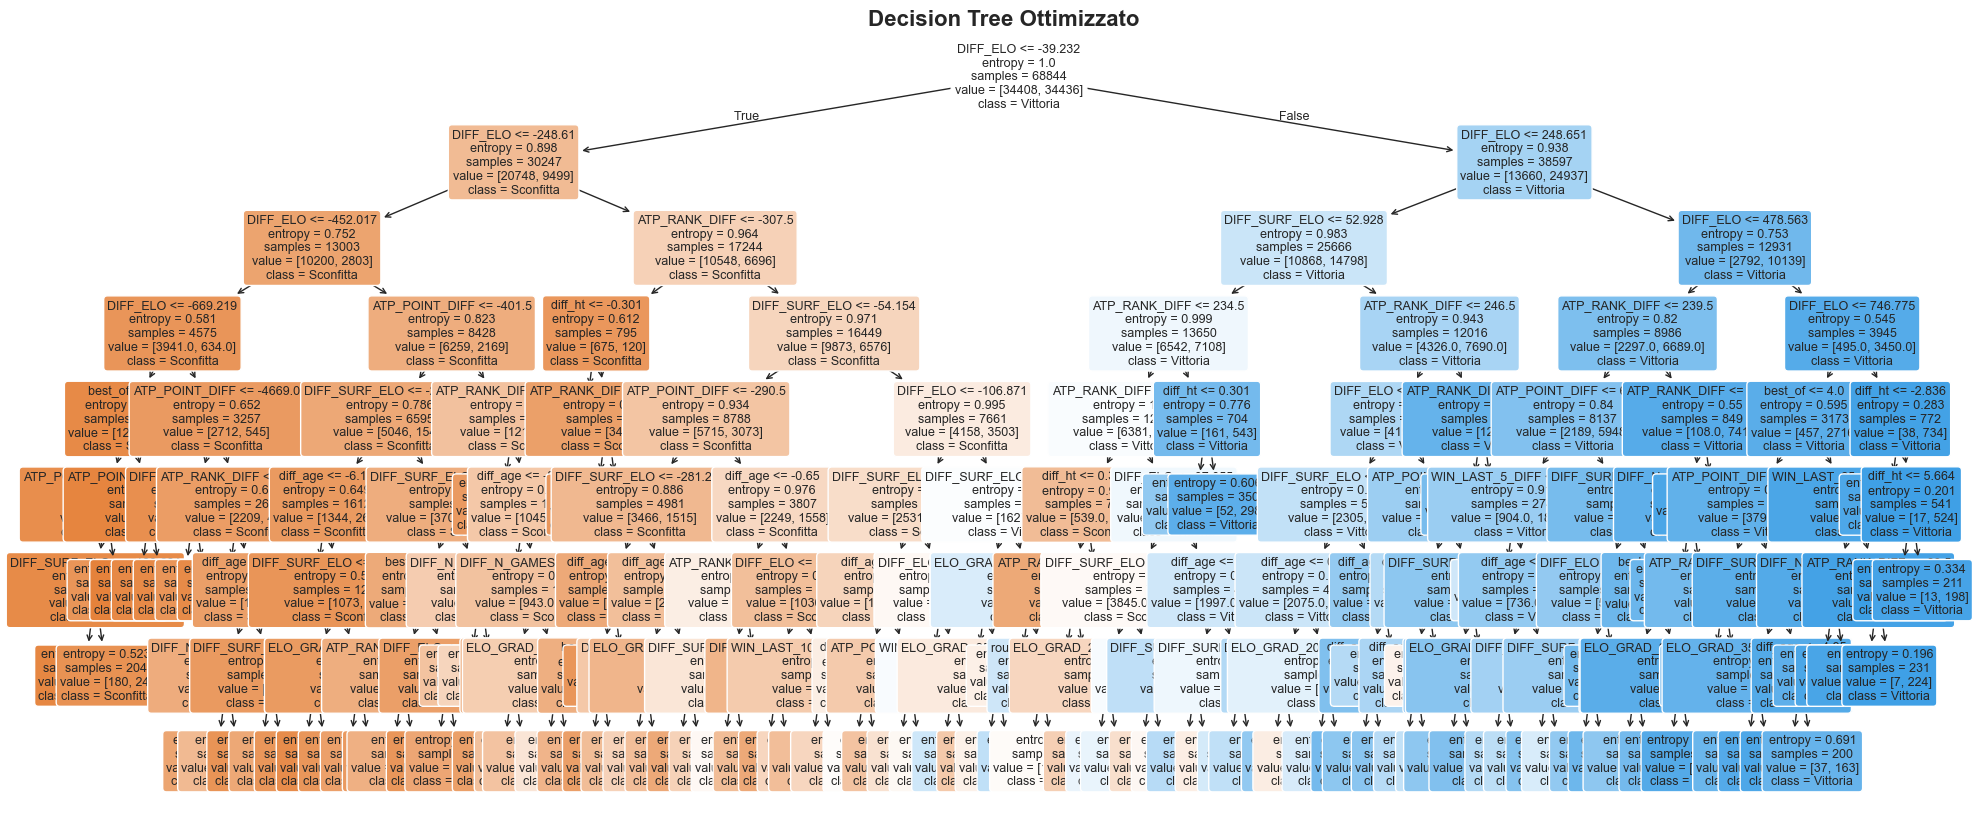

---
### 7.3 Performance e Risultati (Test Set 2023-2024)
Il modello, addestrato su oltre 68.000 partite storiche, è stato testato su un set di dati "out-of-time" di 6.009 match disputati tra il 2023 e il 2024:

Accuracy Globale: Il modello raggiunge il 64.09%. Considerando la volatilità del tennis moderno, è un risultato solido per un singolo albero.

Precision e Recall:

La Precision per la classe 1 (Vittoria) è del 0.65, indicando che quando il modello predice una vittoria del Player 1, indovina nel 65% dei casi.

Il Recall per la classe 1 è del 0.59, evidenziando che il modello tende ad essere leggermente conservativo nelle sue previsioni di vittoria.

F1-Score: Il valore bilanciato di 0.64 (macro average) conferma che il modello non presenta bias significativi verso una delle due classi.

---
### 7.4 Feature Importance Analysis

Come illustrato nel grafico Top 20 Features Importance, il modello mostra una gerarchia di variabili netta. La dominanza della differenza ELO `DIFF_ELO` conferma che questa sia la variabile principale nel predirre la vittoria. Il contributo di variabili come `DIFF_SURF_ELO` e `diff_age` dimostra come il modello riesce a correggere la previsione in caso di condizioni specifiche del match. 

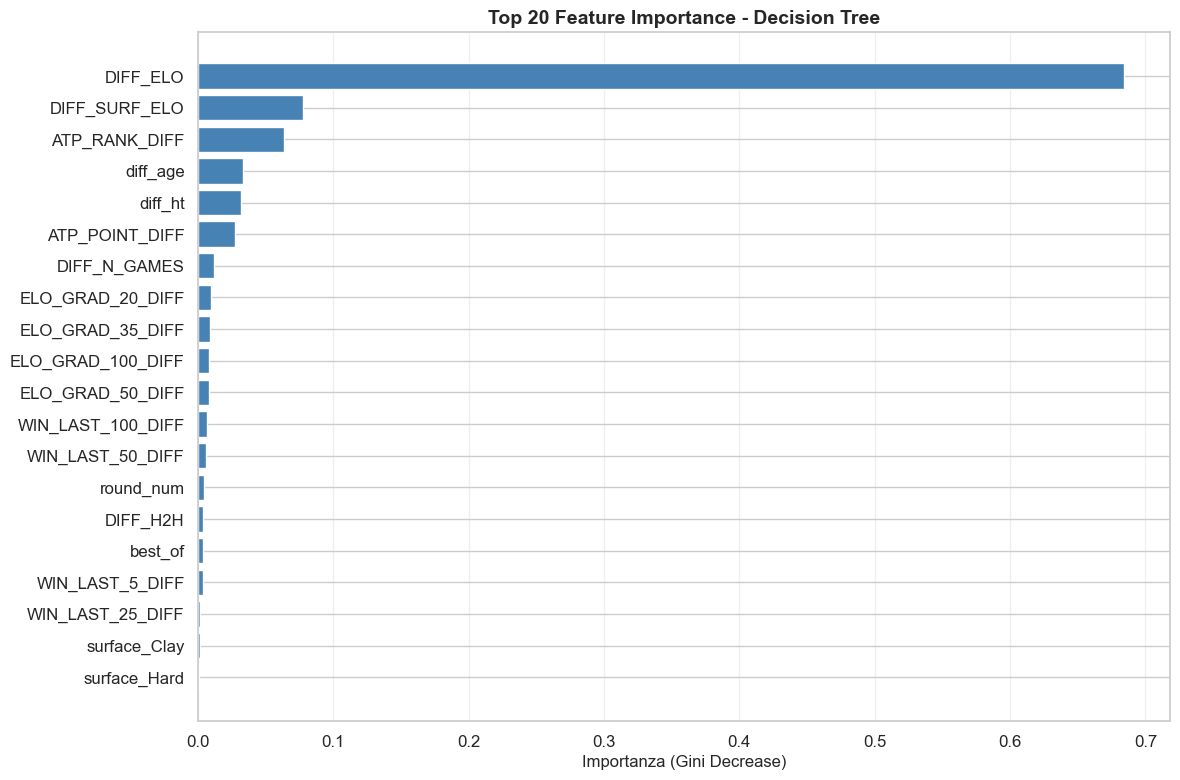

---
### 7.5 Analisi della convergenza (Learning Curves)

L'analisi delle curve di apprendimento ci permette di valutare il bilanciamento tra bias (errore di appossimazione) e varianza (overfitting):
- Assenza di Overfitting: Le curve di Training Accuracy (blu) e Validation Accuracy (rossa) sono vicine lungo tutto l'asse x. Questo conferma che il limite `max_depth=6` e il minimo di 200 campioni per foglia sono efficaci nel prevenire sovra-addestramento. 
- Stabilità: Entrambe le curve raggiungono una fase di stabilità già intorno ai 20.000-25.000 campioni. Questo indica che addestrare ulteriormente il modello oltre questa soglia non porta a miglioramenti significativi della performance
- Generalizzazione Ottimale: Il fatto che la precisione di validazione segua quella di addestramento suggerisce che il modello ha un ottima capacità di generalizzare su dati mai visti. 

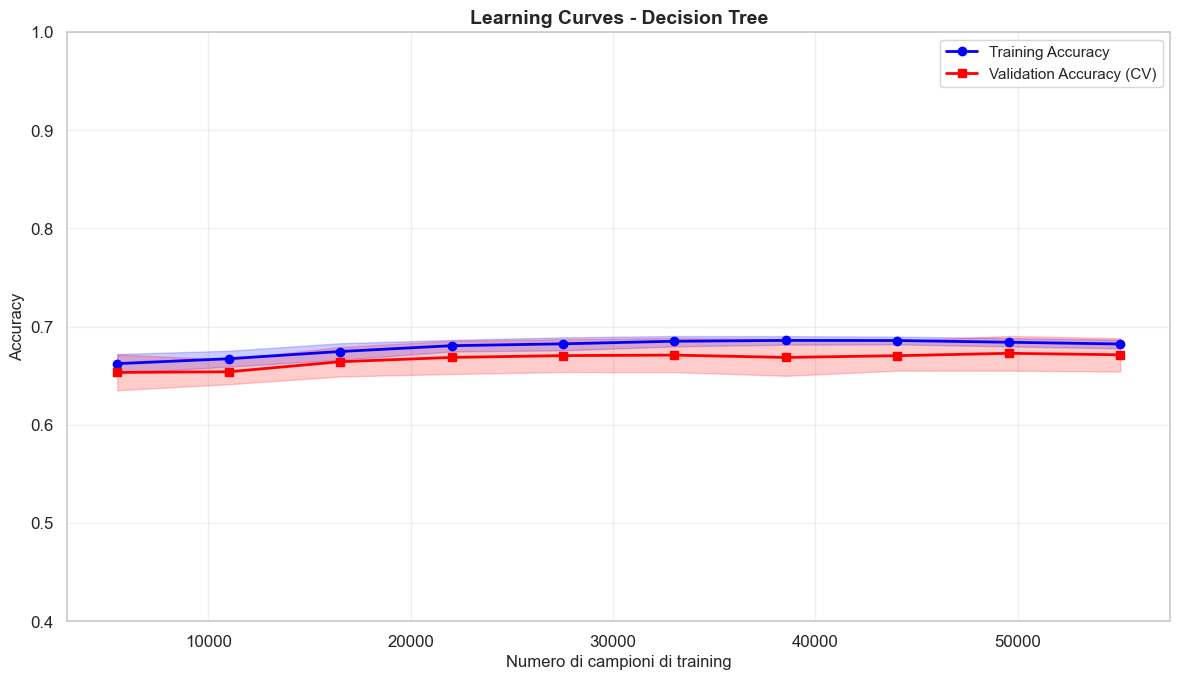


---
---

## 8. Modellazione: Rete Neurale (MLP) con Ottimizzazione
Per superare i limiti strutturali del Decision Tree, abbiamo implementato una Rete Neurale Artificiale (Multi-Layer Perceptron). Questo modello è in grado di apprendere complesse interazioni non lineari tra le feature, come il peso della superficie rispetto all'ELO o l'impatto della forma fisica in relazione all'età.

### 8.1 Strategia di Ottimizzazione (Grid Search)
Invece di scegliere arbitrariamente l'architettura, abbiamo eseguito una Grid Search con Cross-Validation a 3 fold per identificare la configurazione migliore tra 72 combinazioni possibili. I parametri vincenti estratti sono:
- Architettura: 4 strati nascosti con struttura a imbuto (128, 128, 64, 32).
- Funzione di Attivazione: ReLU, ideale per evitare la scomparsa del gradiente in reti profonde.
- Regolarizzazione (Alpha): 0.001, fondamentale per prevenire l'overfitting dato l'elevato numero di parametri.

---
### 8.2 Analisi dell'Apprendimento
La Curva di Apprendimento mostra una discesa costante e fluida dell'errore (Training Loss) lungo le iterazioni. Il fatto che la curva non presenti bruschi sbalzi indica che il learning rate (0.001) è ben calibrato e che il processo di ottimizzazione è stabile.

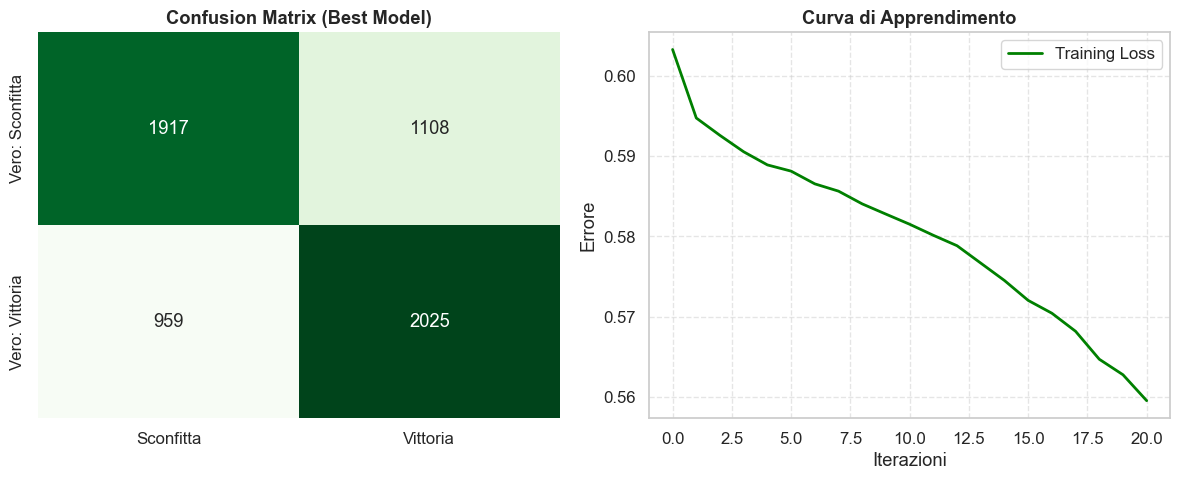

---
### 8.3 Performance sul Test Set (2023-2024)
L'applicazione del miglior modello sui dati "inediti" del biennio 2023-2024 ha prodotto i seguenti risultati:

- Accuratezza Finale: 65.60%. Questo valore segna un netto miglioramento (+1.5% circa) rispetto al Decision Tree, dimostrando che la Rete Neurale riesce a estrarre valore dai segnali più deboli presenti nel dataset.

- Matrice di Confusione:

    - Il modello ha predetto correttamente 2025 vittorie e 1917 sconfitte.

    - Si osserva un bilanciamento tra falsi positivi (1108) e falsi negativi (959), indicando una previsione molto equilibrata tra le due classi.

---
### 8.4 Distribuzione delle probabilità

L'istogramma della Distribuzione delle probabilità di Vittoria rileva l'onestà del modello:
- Incertezza: La maggior parte delle previsioni si concentra tra lo 0,4 e lo 0,6. Questo riflette la natura imprevedibile del tennis: molti match sono equilibrati e il modello non assegna probabilità estreme se non in situazioni di divario schiacciante. 
- Simmetria: La distribuzione quasi perfettamente normale attorno lo 0,5 conferma che il Random Swap ha eliminato ogni bias posizionale (nessun vantaggio fittizio al player 1)

---
### 8.5 Sensibilità al Contesto (Accuracy per Categoria Torneo)

L'analisi delle performance rivela che l'efficacia predittiva della Rete Neurale non è uniforme, ma varia sensibilmente in base al prestigio e al formato del torneo. Questa divergenza rappresenta l'analisi più significativa dal punto di vista tennistico, poiché dimostra come il modello risenta direttamente della struttura della competizione.
- Accuratezza negli slam: L'accuratezza massima si registra negli Slam (oltre il 70%). Questo conferma l'ipotesi tecnica secondo cui, sui cinque set, il valore reale dei giocatori (catturato dall'ELO) ha più tempo per emergere, riducendo l'impatto dei singoli episodi fortuiti.
- Volatilità negli ATP 250/500: L'accuratezza scende sotto la media globale nei tornei minori. In questi contesti la concentrazione e la voglia di vincere dei campioni scende, portando più volte a risultati inattesi.
- Validità della gerarchia: Si osserva un calo progressivo e coerente dell'accuratezza seguendo la gerarchia Grandi Slam, Masters 1000, ATP 500/250. Questo trend convalida in modo empirico la scelta di utilizzare un K-Factor differenziato. Il modello conferma che i risultati ottenuti nei tornei superiori siano più indicativi e affidabili sulla reale forma rispetto a quelli inferiori. 

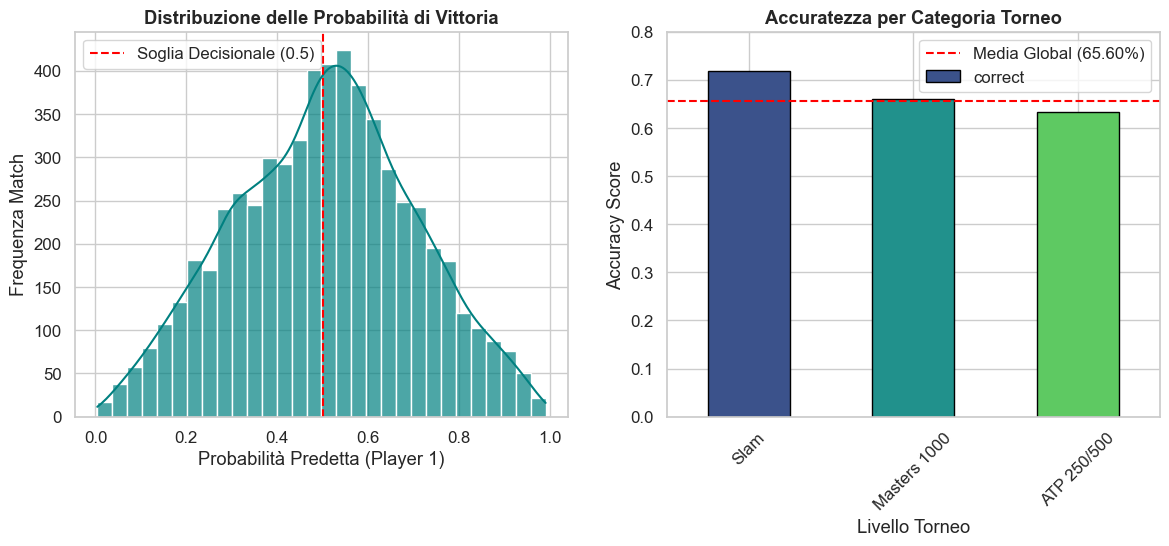

---
---

## 9. Validazione e Risultati

Abbiamo messo alla prova i modelli su 6.009 partite (test set 2023-2024).

### 9.1 Confronto prestazioni: Decision Tree vs Rete Neurale

La Rete Neurale si aggiudica il titolo di miglior modello: non solo è più precisa, ma dimostra una capacità superiore di classificare correttamente sia le vittorie che le sconfitte, come evidenziato dal miglioramento nel Recall per la classe 1 (vittoria) che passa dal 0.59 del Decision Tree allo 0.68 della Rete Neurale.

Per capire bene se i modelli funzionano veramente o sono solo stati fortunati, analizziamo i grafici:

- Curva ROC (Ranking): La curva della Rete Neurale (arancione) sovrasta costantemente quella del Decision Tree (blu), raggiungendo un AUC di 0.72. Questo indica che il modello è molto efficace nel distinguere tra un match "scontato" e un possibile upset.
- Affidabilità delle Probabilità (Calibration Curve): Entrambi i modelli seguono molto bene la diagonale tratteggiata. Questo è un risultato straordinario: significa che se il tuo modello predice l'80% di probabilità per Sinner, Sinner vince davvero circa l'80% delle volte nella realtà. La Rete Neurale appare leggermente più stabile e meno soggetta a "salti" rispetto all'albero.

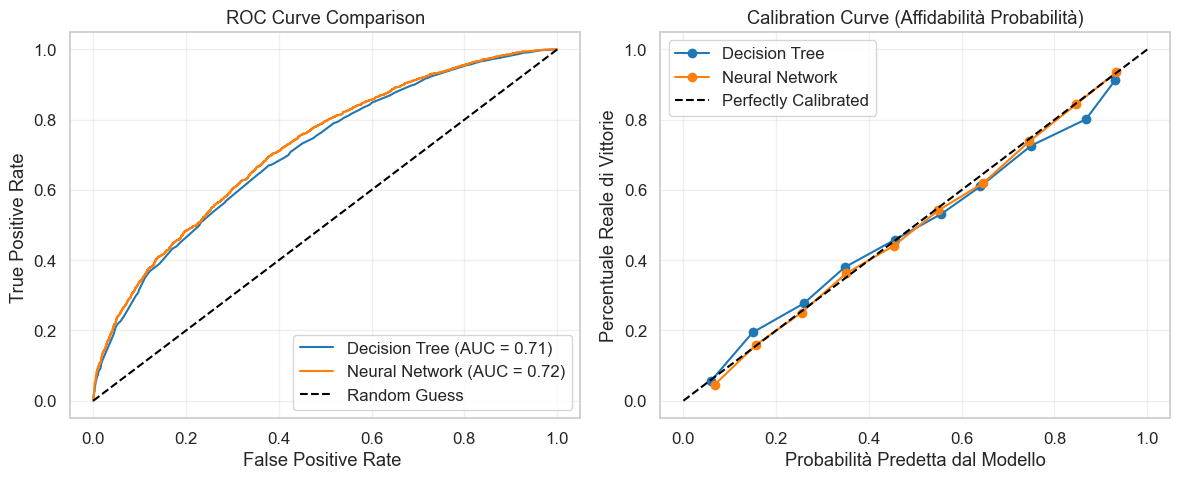

---
### 9.2 Perché la rete neurale ha vinto?
I risultati riflettono quanto scoperto nelle fasi precedenti:

1. Sintesi delle Feature: La PCA ci aveva avvertito che l'80% dell'info era sparsa su 16 componenti. Mentre l'albero si concentra su pochi split (il primo è DIFF_ELO <= -39.232), la Rete Neurale riesce a pesare contemporaneamente tutte le 57 variabili, inclusi i gradienti di forma e i dati fisici.
2. Ottimizzazione Profonda: La Grid Search ha permesso di trovare un'architettura a imbuto (128-128-64-32) e una regolarizzazione (Alpha 0.01) che estraggono segnale anche dai match più equilibrati, dove l'albero tendeva ad avere un'entropia troppo alta.
